# 05 — Multistream validation (`SigCWGAN`, `Neural SDE`, `Diffusion`)

This notebook is the shared **consumer-side validation notebook** for the current project streams.

It extends the old `05_s2_validation.ipynb` and keeps the same spirit:
- load a real reference parquet
- load a synthetic parquet
- run a fixed battery of validation tests
- save a JSON report plus figures

What is added here:
- split-aware evaluation (`train` / `val` / `test` / `all`)
- dynamic regime handling, including `regime_refined`
- support for either `logsig` inputs or raw wide path inputs
- richer validation metrics covering:
  - distributional fidelity
  - temporal structure
  - regime-conditional quality
  - tail behaviour
  - event proxy realism
  - optional structural checks when the needed columns are genuinely available

This notebook is designed to be reused across:
- Stream 3 — SigCWGAN
- Stream 4 — Neural SDE
- Stream 5 — Diffusion


In [17]:

%pip install -q pandas pyarrow matplotlib numpy scipy scikit-learn statsmodels iisignature

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
from IPython.display import display
import json
import math
import re
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import rbf_kernel
from statsmodels.tsa.stattools import acf

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DATA_DIR = Path("/content/drive/MyDrive/energy_synthetic_data/data")
NOTEBOOK_DIR = Path("/content/drive/MyDrive/energy_synthetic_data/notebooks")

assert DATA_DIR.exists(), f"DATA_DIR not found: {DATA_DIR}"
assert NOTEBOOK_DIR.exists(), f"NOTEBOOK_DIR not found: {NOTEBOOK_DIR}"

# ═══════════════════════════════════════════════════════════════════════════
# CELL 1 — Configuration: change these for each model
# ═══════════════════════════════════════════════════════════════════════════

MODEL_NAME = "raw_pat_sigCWGAN_s3"
REAL_FILE = DATA_DIR / "logsigs_s3.parquet"
SYNTH_FILE = DATA_DIR / "sigcwgan_generated_logsigs_optuna_rawproxy_v1.parquet"

# "auto", "logsigs", or "raw_paths"
REAL_FORMAT = "auto"
SYNTH_FORMAT = "auto"

# Usually "test" for honest comparison. Use "all" only when you really mean it.
TARGET_SPLIT = "test"   # "train" | "val" | "test" | "all"

# Dynamic regime view
REGIME_MODE = "auto"    # "auto" | "refined" | "coarse4"

# Raw-path handling
COMPUTE_LOGSIGS_FROM_RAW = True
RAW_LOGSIG_DEPTH = 2
RAW_MIN_CHANNEL_LEN = 16
RAW_MAX_CHANNELS = 4
RAW_CHANNEL_PREFERENCE = [
    "price_", "price", "log_price_", "log_price",
    "ret_", "return_", "returns_",
    "wind_", "wind",
    "lambda_spike_", "lambda_spike",
    "lambda_neg_", "lambda_neg",
]

# Metric controls
MAX_LAGS = 24
MIN_REGIME_SAMPLES = 20
N_MMD = 1000
MMD_GAMMA = None       # None -> median heuristic
TAIL_ALPHA = 0.05
EVENT_Q = 0.95

# Composite score weights (lower is better)
SCORE_WEIGHTS = {
    "mmd": 1.0,
    "mean_gap": 0.25,
    "std_gap": 1.0,
    "acf_gap": 0.5,
    "levy_gap": 0.25,
    "tail_gap": 0.5,
    "event_gap": 0.5,
}

OUTPUT_JSON = DATA_DIR / f"validation_{MODEL_NAME}.json"
FIG_DIR = DATA_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("MODEL_NAME :", MODEL_NAME)
print("REAL_FILE  :", REAL_FILE)
print("SYNTH_FILE :", SYNTH_FILE)
print("TARGET_SPLIT:", TARGET_SPLIT)
print("OUTPUT_JSON:", OUTPUT_JSON)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MODEL_NAME : raw_pat_sigCWGAN_s3
REAL_FILE  : /content/drive/MyDrive/energy_synthetic_data/data/logsigs_s3.parquet
SYNTH_FILE : /content/drive/MyDrive/energy_synthetic_data/data/sigcwgan_generated_logsigs_optuna_rawproxy_v1.parquet
TARGET_SPLIT: test
OUTPUT_JSON: /content/drive/MyDrive/energy_synthetic_data/data/validation_raw_pat_sigCWGAN_s3.json


In [18]:

# ═══════════════════════════════════════════════════════════════════════════
# CELL 2 — Helpers
# ═══════════════════════════════════════════════════════════════════════════

COARSE_REGIME_MAP = {
    "calm": "calm",
    "volatile": "volatile",
    "spike": "spike",
    "negative": "negative",
    "calm_low_wind_calm": "calm",
    "calm_mid_wind_calm": "calm",
    "calm_high_wind_calm": "calm",
    "spike_moderate_brief": "spike",
    "spike_moderate_sustained": "spike",
    "spike_extreme_brief": "spike",
    "spike_extreme_sustained": "spike",
}

def safe_float(x):
    if x is None:
        return None
    try:
        x = float(x)
        if not np.isfinite(x):
            return None
        return x
    except Exception:
        return None

def recompute_blocked_split_labels(
    df: pd.DataFrame,
    train_frac: float = 0.70,
    val_frac: float = 0.15,
    test_frac: float = 0.15,
    embargo_halfhours: int = 72,
    step_size: int = 24,
    sort_col: str = "start_idx",
) -> pd.Series:
    """
    Defensive split reconstruction for Stream 3/4/5 validation.

    Ignores any saved 'split' column and rebuilds the blocked chronological split
    from row order / start_idx, because saved labels may be wrong upstream.
    """
    if abs(train_frac + val_frac + test_frac - 1.0) > 1e-9:
        raise ValueError("train_frac + val_frac + test_frac must sum to 1.")

    n = len(df)
    if n == 0:
        return pd.Series([], dtype=object, index=df.index)

    work = df.copy()

    if sort_col in work.columns:
        work = work.sort_values(sort_col).copy()
    elif "start_time" in work.columns:
        work = work.sort_values("start_time").copy()
    else:
        work = work.reset_index(drop=False).copy()

    embargo_segments = int(np.ceil(embargo_halfhours / step_size))

    n_train = int(np.floor(train_frac * n))
    n_val = int(np.floor(val_frac * n))
    # test gets the remainder after train/val and embargo gaps
    split = np.array(["unused"] * n, dtype=object)

    train_end = n_train
    val_start = min(n, train_end + embargo_segments)
    val_end = min(n, val_start + n_val)
    test_start = min(n, val_end + embargo_segments)

    split[:train_end] = "train"
    split[val_start:val_end] = "val"
    split[test_start:] = "test"

    out = pd.Series(split, index=work.index, name="split_recomputed")
    out = out.reindex(df.index)
    return out

def apply_split_filter(df: pd.DataFrame, target_split: str) -> pd.DataFrame:
    if target_split is None or str(target_split).lower() == "all":
        out = df.copy()
        out["split_recomputed"] = recompute_blocked_split_labels(out)
        print(f"[info] split=all: kept {len(out)} / {len(df)} rows")
        return out

    out = df.copy()
    out["split_recomputed"] = recompute_blocked_split_labels(out)

    kept = out.loc[
        out["split_recomputed"].astype(str).str.lower() == str(target_split).lower()
    ].copy()

    print(
        f"[info] recomputed split={target_split}: kept {len(kept)} / {len(df)} rows "
        f"(saved split column ignored)"
    )
    return kept

def get_logsig_cols(df: pd.DataFrame):
    cols = [c for c in df.columns if str(c).startswith("ls_")]
    def key_fn(x):
        try:
            return int(str(x).split("_")[1])
        except Exception:
            return str(x)
    return sorted(cols, key=key_fn)

def infer_format(df: pd.DataFrame, declared: str = "auto") -> str:
    declared = str(declared).lower()
    if declared in {"logsigs", "raw_paths"}:
        return declared
    ls_cols = get_logsig_cols(df)
    if ls_cols:
        return "logsigs"
    raw_groups = find_numeric_channel_groups(df.columns, min_len=RAW_MIN_CHANNEL_LEN)
    if raw_groups:
        return "raw_paths"
    return "unknown"

def find_numeric_channel_groups(columns, min_len: int = 16):
    groups = defaultdict(list)
    pat = re.compile(r"^(.*?)(\d+)$")
    for c in map(str, columns):
        m = pat.match(c)
        if m:
            prefix = m.group(1)
            idx = int(m.group(2))
            groups[prefix].append((idx, c))
    cleaned = {}
    for prefix, vals in groups.items():
        vals = sorted(vals)
        idxs = [i for i, _ in vals]
        if len(idxs) < min_len:
            continue
        # Accept contiguous from 0 or 1
        start = idxs[0]
        if idxs == list(range(start, start + len(idxs))):
            cleaned[prefix] = [c for _, c in vals]
    return cleaned

def choose_shared_raw_channels(groups_real, groups_synth, preference, max_channels=4):
    shared = [g for g in groups_real if g in groups_synth and len(groups_real[g]) == len(groups_synth[g])]
    if not shared:
        return []
    ordered = []
    used = set()
    for pref in preference:
        for g in shared:
            if g.startswith(pref) or g == pref:
                if g not in used:
                    ordered.append(g)
                    used.add(g)
    for g in shared:
        if g not in used:
            ordered.append(g)
            used.add(g)
    return ordered[:max_channels]

def build_path_cube(df: pd.DataFrame, channel_groups):
    if not channel_groups:
        return None
    mats = []
    for prefix in channel_groups:
        cols = channel_groups[prefix]
        mats.append(df[cols].to_numpy(dtype=np.float64))
    # [n, T, d]
    return np.stack(mats, axis=-1)

def compute_logsignatures_from_paths(path_cube: np.ndarray, depth: int = 2):
    import iisignature
    if path_cube is None:
        return None, []
    n, T, d = path_cube.shape
    spec = iisignature.prepare(d, depth)
    out = np.zeros((n, iisignature.logsiglength(d, depth)), dtype=np.float64)
    for i in range(n):
        out[i] = iisignature.logsig(path_cube[i], spec)
    cols = [f"ls_{j+1}" for j in range(out.shape[1])]
    return out, cols

def stable_series_equal(a: pd.Series, b: pd.Series) -> bool:
    if len(a) != len(b):
        return False
    try:
        av = a.to_numpy()
        bv = b.to_numpy()
        if av.dtype.kind in "if" or bv.dtype.kind in "if":
            return np.allclose(pd.to_numeric(a, errors="coerce"), pd.to_numeric(b, errors="coerce"), equal_nan=True)
        return np.array_equal(av, bv)
    except Exception:
        return False

def get_regimes(df: pd.DataFrame, mode: str = "auto"):
    if "regime" not in df.columns:
        return np.array(["unknown"] * len(df)), "missing"
    reg = df["regime"].astype(str).fillna("unknown").to_numpy()
    if mode == "refined":
        return reg, "refined"
    if mode == "coarse4":
        coarse = np.array([COARSE_REGIME_MAP.get(x, x) for x in reg], dtype=object)
        return coarse, "coarse4"
    # auto
    unique = set(reg.tolist())
    if any(x in unique for x in ["calm_low_wind_calm", "spike_extreme_sustained", "spike_moderate_brief"]):
        return reg, "refined"
    return np.array([COARSE_REGIME_MAP.get(x, x) for x in reg], dtype=object), "coarse4"

def make_return_proxy(X: np.ndarray, ls_cols, path_cube=None, channel_names=None):
    if X is not None and "ls_1" in ls_cols:
        return X[:, ls_cols.index("ls_1")]
    if path_cube is not None and channel_names:
        # prefer price-like channels, otherwise first channel net change
        pref_rank = [
            "price_", "price", "log_price_", "log_price",
            "ret_", "return_", "returns_",
        ]
        idx = 0
        for p in pref_rank:
            for j, name in enumerate(channel_names):
                if name.startswith(p) or name == p:
                    idx = j
                    break
        return path_cube[:, -1, idx] - path_cube[:, 0, idx]
    if X is not None:
        return X[:, 0]
    raise ValueError("Could not build return proxy.")

def make_aux_proxy(X: np.ndarray, ls_cols, path_cube=None):
    if X is not None:
        return np.linalg.norm(X[:, : min(10, X.shape[1])], axis=1)
    if path_cube is not None:
        return np.std(np.diff(path_cube[:, :, 0], axis=1), axis=1)
    return None

def left_cvar(x, alpha=0.05):
    x = np.asarray(x, dtype=np.float64)
    q = np.quantile(x, alpha)
    tail = x[x <= q]
    return float(np.mean(tail)) if len(tail) else np.nan

def right_cvar(x, alpha=0.05):
    x = np.asarray(x, dtype=np.float64)
    q = np.quantile(x, 1 - alpha)
    tail = x[x >= q]
    return float(np.mean(tail)) if len(tail) else np.nan

def hill_estimator_abs(x, k=None):
    x = np.abs(np.asarray(x, dtype=np.float64))
    x = x[np.isfinite(x)]
    x = x[x > 0]
    if len(x) < 20:
        return np.nan
    x = np.sort(x)[::-1]
    if k is None:
        k = max(10, min(len(x) // 10, 100))
    if k >= len(x):
        return np.nan
    top = x[:k]
    xk1 = x[k]
    if xk1 <= 0:
        return np.nan
    return float(np.mean(np.log(top / xk1)))

def mean_std_gaps(X_real, X_synth):
    mu_r = X_real.mean(axis=0)
    mu_s = X_synth.mean(axis=0)
    sd_r = X_real.std(axis=0)
    sd_s = X_synth.std(axis=0)
    mean_gap = float(np.mean(np.abs(mu_r - mu_s)))
    std_gap = float(np.mean(np.abs(sd_r - sd_s)))
    return mean_gap, std_gap, mu_r, mu_s, sd_r, sd_s

def acf_gap(x_real, x_synth, nlags=24):
    nl = min(nlags, max(1, len(x_real) - 2), max(1, len(x_synth) - 2))
    if nl < 2:
        return np.nan, None, None
    a_r = acf(np.asarray(x_real, dtype=np.float64), nlags=nl, fft=True)
    a_s = acf(np.asarray(x_synth, dtype=np.float64), nlags=nl, fft=True)
    gap = float(np.mean(np.abs(a_r - a_s)))
    return gap, a_r, a_s

def ar1_half_life(x):
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if len(x) < 10:
        return np.nan
    x0 = x[:-1] - np.mean(x[:-1])
    x1 = x[1:] - np.mean(x[1:])
    denom = np.dot(x0, x0)
    if denom <= 1e-12:
        return np.nan
    phi = float(np.dot(x0, x1) / denom)
    if abs(phi) >= 1 or abs(phi) <= 1e-8:
        return np.nan
    return float(np.log(0.5) / np.log(abs(phi)))

def transition_matrix(labels):
    labels = list(map(str, labels))
    uniq = sorted(set(labels))
    idx = {u: i for i, u in enumerate(uniq)}
    mat = np.zeros((len(uniq), len(uniq)), dtype=np.float64)
    if len(labels) < 2:
        return uniq, mat
    for a, b in zip(labels[:-1], labels[1:]):
        mat[idx[a], idx[b]] += 1
    row_sums = mat.sum(axis=1, keepdims=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        mat = np.divide(mat, row_sums, out=np.zeros_like(mat), where=row_sums > 0)
    return uniq, mat

def matrix_l1_gap(A, B):
    if A.shape != B.shape:
        return np.nan
    return float(np.mean(np.abs(A - B)))

def beta_of_y_on_x(y, x):
    y = np.asarray(y, dtype=np.float64)
    x = np.asarray(x, dtype=np.float64)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 10:
        return np.nan
    X = np.column_stack([np.ones(mask.sum()), x[mask]])
    beta = np.linalg.lstsq(X, y[mask], rcond=None)[0]
    return float(beta[1])

def median_heuristic_gamma(X):
    if len(X) < 5:
        return 1.0
    idx = np.random.choice(len(X), size=min(300, len(X)), replace=False)
    Z = X[idx]
    d2 = np.sum((Z[:, None, :] - Z[None, :, :]) ** 2, axis=2)
    d2 = d2[np.triu_indices_from(d2, k=1)]
    med = np.median(d2[d2 > 0]) if np.any(d2 > 0) else 1.0
    return 1.0 / max(med, 1e-8)

def rbf_mmd(X_real, X_synth, gamma=None):
    Z = np.vstack([X_real, X_synth])
    if gamma is None:
        gamma = median_heuristic_gamma(Z)
    Kxx = rbf_kernel(X_real, X_real, gamma=gamma)
    Kyy = rbf_kernel(X_synth, X_synth, gamma=gamma)
    Kxy = rbf_kernel(X_real, X_synth, gamma=gamma)
    mmd = Kxx.mean() + Kyy.mean() - 2 * Kxy.mean()
    return float(mmd), float(gamma)

def normalise_for_kernel(X_real, X_synth):
    mu = X_real.mean(axis=0)
    sd = X_real.std(axis=0)
    sd[sd < 1e-8] = 1.0
    return (X_real - mu) / sd, (X_synth - mu) / sd

def maybe_find_uncopied_numeric_pair(df_real, df_synth, y_candidates, x_candidates):
    for y in y_candidates:
        for x in x_candidates:
            if y in df_real.columns and x in df_real.columns and y in df_synth.columns and x in df_synth.columns:
                if stable_series_equal(df_real[y], df_synth[y]) and stable_series_equal(df_real[x], df_synth[x]):
                    continue
                return y, x
    return None, None

def event_indicator(x, q):
    thr = np.quantile(np.abs(x), q)
    return (np.abs(x) >= thr).astype(float), float(thr)

def summary_stats(x):
    x = np.asarray(x, dtype=np.float64)
    return {
        "mean": safe_float(np.mean(x)),
        "std": safe_float(np.std(x)),
        "skew": safe_float(stats.skew(x, nan_policy="omit")),
        "kurtosis": safe_float(stats.kurtosis(x, fisher=False, nan_policy="omit")),
        "min": safe_float(np.min(x)),
        "max": safe_float(np.max(x)),
        "q05": safe_float(np.quantile(x, 0.05)),
        "q50": safe_float(np.quantile(x, 0.50)),
        "q95": safe_float(np.quantile(x, 0.95)),
    }

print("Helpers loaded.")


Helpers loaded.


In [19]:

# ═══════════════════════════════════════════════════════════════════════════
# CELL 3 — Load data and build shared representation
# ═══════════════════════════════════════════════════════════════════════════

assert REAL_FILE.exists(), f"Missing real file: {REAL_FILE}"
assert SYNTH_FILE.exists(), f"Missing synthetic file: {SYNTH_FILE}"

df_real_raw = pd.read_parquet(REAL_FILE)
df_synth_raw = pd.read_parquet(SYNTH_FILE)

df_real = apply_split_filter(df_real_raw, TARGET_SPLIT)
df_synth = apply_split_filter(df_synth_raw, TARGET_SPLIT)

real_format = infer_format(df_real, REAL_FORMAT)
synth_format = infer_format(df_synth, SYNTH_FORMAT)

print("Detected formats:")
print("  real :", real_format)
print("  synth:", synth_format)

# Build comparable representation
ls_cols_real = get_logsig_cols(df_real)
ls_cols_synth = get_logsig_cols(df_synth)

X_real = None
X_synth = None
ls_cols = []

path_cube_real = None
path_cube_synth = None
path_channels = []

if ls_cols_real and ls_cols_synth:
    ls_cols = sorted(set(ls_cols_real) & set(ls_cols_synth), key=lambda x: int(x.split("_")[1]))
    X_real = df_real[ls_cols].to_numpy(dtype=np.float64)
    X_synth = df_synth[ls_cols].to_numpy(dtype=np.float64)
    representation_mode = "logsigs_direct"
else:
    groups_real = find_numeric_channel_groups(df_real.columns, min_len=RAW_MIN_CHANNEL_LEN)
    groups_synth = find_numeric_channel_groups(df_synth.columns, min_len=RAW_MIN_CHANNEL_LEN)
    shared_channels = choose_shared_raw_channels(groups_real, groups_synth, RAW_CHANNEL_PREFERENCE, RAW_MAX_CHANNELS)
    if shared_channels:
        path_channels = shared_channels
        path_cube_real = build_path_cube(df_real, {k: groups_real[k] for k in shared_channels})
        path_cube_synth = build_path_cube(df_synth, {k: groups_synth[k] for k in shared_channels})
        if COMPUTE_LOGSIGS_FROM_RAW:
            X_real, ls_cols = compute_logsignatures_from_paths(path_cube_real, depth=RAW_LOGSIG_DEPTH)
            X_synth, _ = compute_logsignatures_from_paths(path_cube_synth, depth=RAW_LOGSIG_DEPTH)
            representation_mode = "raw_paths_to_logsigs"
        else:
            representation_mode = "raw_paths_only"
    else:
        representation_mode = "no_shared_representation"

print("Representation mode:", representation_mode)

if X_real is not None and X_synth is not None:
    print("  common representation shape:", X_real.shape, X_synth.shape)
    assert X_real.shape[1] == X_synth.shape[1]
else:
    print("[warn] No shared log-signature representation available. Logsig-based tests will be skipped.")

regimes_real, regime_mode_real = get_regimes(df_real, REGIME_MODE)
regimes_synth, regime_mode_synth = get_regimes(df_synth, REGIME_MODE)

if regime_mode_real != regime_mode_synth:
    print(f"[warn] Regime mode mismatch: real={regime_mode_real}, synth={regime_mode_synth}")

print("Regime mode used:", regime_mode_real)
print("Top real regimes :", Counter(regimes_real).most_common(10))
print("Top synth regimes:", Counter(regimes_synth).most_common(10))

return_real = make_return_proxy(X_real, ls_cols, path_cube_real, path_channels) if (X_real is not None or path_cube_real is not None) else None
return_synth = make_return_proxy(X_synth, ls_cols, path_cube_synth, path_channels) if (X_synth is not None or path_cube_synth is not None) else None

aux_real = make_aux_proxy(X_real, ls_cols, path_cube_real)
aux_synth = make_aux_proxy(X_synth, ls_cols, path_cube_synth)

copied_meta_flags = {}
for c in ["split", "regime", "mean_price", "mean_wind", "realised_vol", "seg_lambda_spike_mean", "seg_lambda_neg_mean", "seg_lambda_spike_max"]:
    if c in df_real.columns and c in df_synth.columns:
        copied_meta_flags[c] = bool(stable_series_equal(df_real[c], df_synth[c]))
    else:
        copied_meta_flags[c] = None

print("Potentially copied helper/meta columns:")
for k, v in copied_meta_flags.items():
    print(f"  {k}: {v}")


[info] recomputed split=test: kept 972 / 6514 rows (saved split column ignored)
[info] recomputed split=test: kept 969 / 6500 rows (saved split column ignored)
Detected formats:
  real : logsigs
  synth: logsigs
Representation mode: logsigs_direct
  common representation shape: (972, 90) (969, 90)
Regime mode used: refined
Top real regimes : [('volatile', 387), ('negative', 172), ('calm_mid_wind_calm', 131), ('calm_high_wind_calm', 109), ('calm_low_wind_calm', 103), ('spike_extreme_sustained', 40), ('spike_extreme_brief', 30)]
Top synth regimes: [('volatile', 387), ('negative', 169), ('calm_mid_wind_calm', 131), ('calm_high_wind_calm', 109), ('calm_low_wind_calm', 103), ('spike_extreme_sustained', 40), ('spike_extreme_brief', 30)]
Potentially copied helper/meta columns:
  split: False
  regime: False
  mean_price: False
  mean_wind: False
  realised_vol: False
  seg_lambda_spike_mean: False
  seg_lambda_neg_mean: False
  seg_lambda_spike_max: False


In [20]:
# ═══════════════════════════════════════════════════════════════════════════
# DIAGNOSTIC — check row loss before scoring
# Run this AFTER Cell 3
# ═══════════════════════════════════════════════════════════════════════════

def _logsig_cols(df):
    cols = [c for c in df.columns if str(c).startswith("ls_")]
    def _k(x):
        try:
            return int(str(x).split("_")[1])
        except Exception:
            return str(x)
    return sorted(cols, key=_k)

print("REAL_FILE :", REAL_FILE)
print("SYNTH_FILE:", SYNTH_FILE)
print("TARGET_SPLIT:", TARGET_SPLIT)

print("\nRAW SHAPES")
print("  df_real_raw :", df_real_raw.shape)
print("  df_synth_raw:", df_synth_raw.shape)

for name, df_ in [("real_raw", df_real_raw), ("synth_raw", df_synth_raw)]:
    print(f"\n{name.upper()} split counts:")
    if "split" in df_.columns:
        print(df_["split"].astype(str).value_counts(dropna=False).sort_index())
    else:
        print("  no split column")

    if "segment_id" in df_.columns:
        print(f"{name.upper()} unique segment_id:", df_["segment_id"].nunique())
    else:
        print(f"{name.upper()} has no segment_id")

    ls_cols_local = _logsig_cols(df_)
    print(f"{name.upper()} logsig cols:", len(ls_cols_local))
    if ls_cols_local:
        arr = df_[ls_cols_local].to_numpy(dtype=np.float64)
        finite_rows = np.isfinite(arr).all(axis=1)
        print(f"{name.upper()} fully finite ls rows:", int(finite_rows.sum()))

print("\nPOST-SPLIT SHAPES")
print("  df_real :", df_real.shape)
print("  df_synth:", df_synth.shape)

for name, df_ in [("real", df_real), ("synth", df_synth)]:
    if "segment_id" in df_.columns:
        print(f"{name.upper()} unique segment_id:", df_["segment_id"].nunique())

    ls_cols_local = _logsig_cols(df_)
    print(f"{name.upper()} logsig cols:", len(ls_cols_local))
    if ls_cols_local:
        arr = df_[ls_cols_local].to_numpy(dtype=np.float64)
        finite_rows = np.isfinite(arr).all(axis=1)
        print(f"{name.upper()} fully finite ls rows:", int(finite_rows.sum()))

real_ls = _logsig_cols(df_real)
synth_ls = _logsig_cols(df_synth)
common_ls = [c for c in real_ls if c in synth_ls]

print("\nCOMMON REPRESENTATION")
print("  common logsig cols:", len(common_ls))

if common_ls:
    real_arr = df_real[common_ls].to_numpy(dtype=np.float64)
    synth_arr = df_synth[common_ls].to_numpy(dtype=np.float64)
    print("  real finite rows :", int(np.isfinite(real_arr).all(axis=1).sum()))
    print("  synth finite rows:", int(np.isfinite(synth_arr).all(axis=1).sum()))

if "segment_id" in df_real.columns and "segment_id" in df_synth.columns:
    overlap = set(df_real["segment_id"]).intersection(set(df_synth["segment_id"]))
    print("\nsegment_id overlap after split:", len(overlap))

    only_real = len(set(df_real["segment_id"]) - set(df_synth["segment_id"]))
    only_synth = len(set(df_synth["segment_id"]) - set(df_real["segment_id"]))
    print("segment_id only in real :", only_real)
    print("segment_id only in synth:", only_synth)

print("\nFIRST FEW COLUMNS")
print("real :", list(df_real.columns[:20]))
print("synth:", list(df_synth.columns[:20]))

REAL_FILE : /content/drive/MyDrive/energy_synthetic_data/data/logsigs_s3.parquet
SYNTH_FILE: /content/drive/MyDrive/energy_synthetic_data/data/sigcwgan_generated_logsigs_optuna_rawproxy_v1.parquet
TARGET_SPLIT: test

RAW SHAPES
  df_real_raw : (6514, 132)
  df_synth_raw: (6500, 138)

REAL_RAW split counts:
split
test      977
train    4566
val       971
Name: count, dtype: int64
REAL_RAW unique segment_id: 6514
REAL_RAW logsig cols: 90
REAL_RAW fully finite ls rows: 6514

SYNTH_RAW split counts:
split
test      977
train    4554
val       969
Name: count, dtype: int64
SYNTH_RAW unique segment_id: 6500
SYNTH_RAW logsig cols: 90
SYNTH_RAW fully finite ls rows: 6500

POST-SPLIT SHAPES
  df_real : (972, 133)
  df_synth: (969, 139)
REAL unique segment_id: 972
REAL logsig cols: 90
REAL fully finite ls rows: 972
SYNTH unique segment_id: 969
SYNTH logsig cols: 90
SYNTH fully finite ls rows: 969

COMMON REPRESENTATION
  common logsig cols: 90
  real finite rows : 972
  synth finite rows: 969

s

TEST 1: Marginal distribution matching and moment gaps
mean Wasserstein-1 across dims: 0.9329
mean KS statistic across dims:  0.0843
aggregate mean gap:             0.6999
aggregate std gap:              0.6194


,dim,wasserstein_1,ks_stat,mean_real,mean_synth,std_real,std_synth
24,ls_24,8.079141,0.175410,-6.666003,1.128488,23.150728,22.905419
74,ls_74,7.666397,0.164268,-25.869259,-19.795568,37.490676,44.545334
81,ls_81,6.987734,0.071446,-13.855170,-9.643309,58.064384,54.542619
84,ls_84,5.669252,0.066175,40.748483,35.222574,51.506777,47.769494
72,ls_72,4.386970,0.145778,18.511623,15.117604,23.664158,27.794346
22,ls_22,4.047554,0.080448,7.581378,3.891515,23.781772,23.617755
76,ls_76,3.759644,0.094013,7.694294,5.490780,31.310051,28.541995
79,ls_79,3.539496,0.122896,18.132509,15.536974,22.729595,27.123533
85,ls_85,3.360323,0.073383,20.388994,17.059760,25.925811,22.951281
82,ls_82,3.349785,0.073988,20.232401,17.016922,25.884908,24.570713


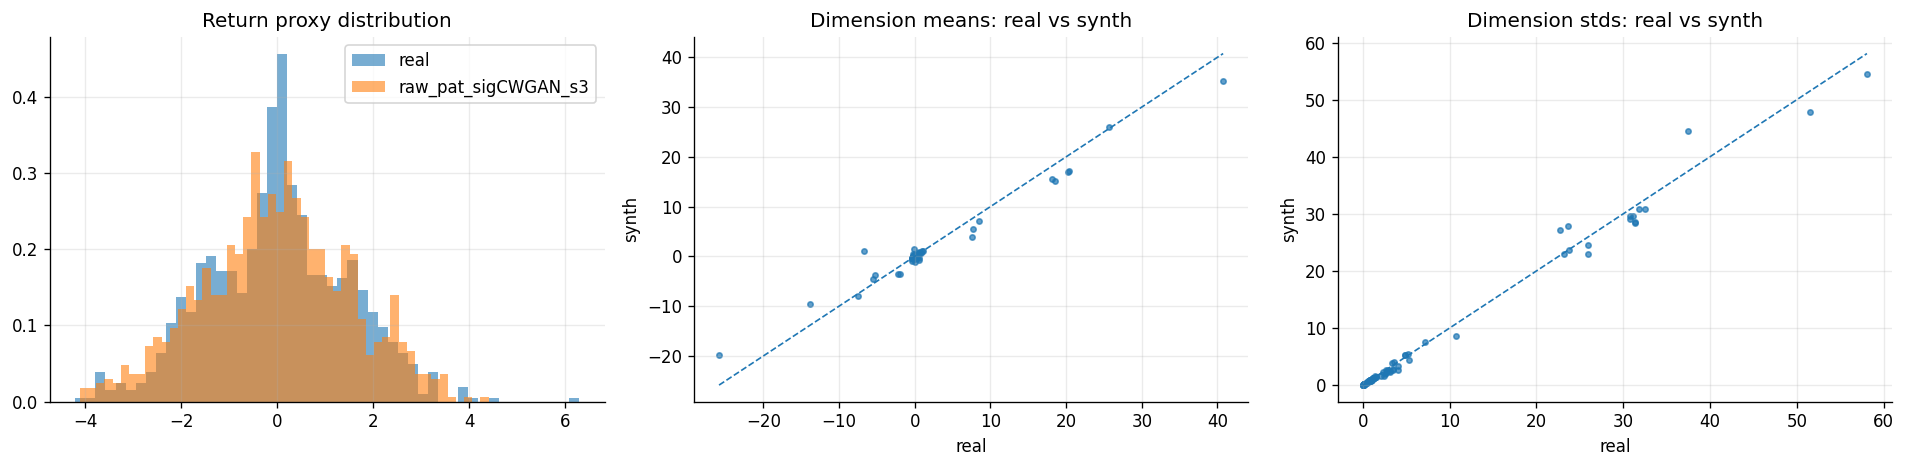

In [21]:

# ═══════════════════════════════════════════════════════════════════════════
# CELL 4 — Test 1: Marginal distribution + moment matching
# ═══════════════════════════════════════════════════════════════════════════

print("=" * 72)
print("TEST 1: Marginal distribution matching and moment gaps")
print("=" * 72)

marginal_results = []
mean_w1 = np.nan
mean_ks = np.nan
mean_gap = np.nan
std_gap = np.nan

if X_real is not None and X_synth is not None:
    from scipy.stats import wasserstein_distance, ks_2samp

    for j, col in enumerate(ls_cols):
        r = X_real[:, j]
        s = X_synth[:, j]
        w1 = wasserstein_distance(r, s)
        ks_stat, ks_p = ks_2samp(r, s)
        marginal_results.append({
            "dim": col,
            "wasserstein_1": float(w1),
            "ks_stat": float(ks_stat),
            "ks_pval": float(ks_p),
            "mean_real": safe_float(np.mean(r)),
            "mean_synth": safe_float(np.mean(s)),
            "std_real": safe_float(np.std(r)),
            "std_synth": safe_float(np.std(s)),
        })

    mean_w1 = float(np.mean([d["wasserstein_1"] for d in marginal_results]))
    mean_ks = float(np.mean([d["ks_stat"] for d in marginal_results]))
    mean_gap, std_gap, mu_r, mu_s, sd_r, sd_s = mean_std_gaps(X_real, X_synth)

    print(f"mean Wasserstein-1 across dims: {mean_w1:.4f}")
    print(f"mean KS statistic across dims:  {mean_ks:.4f}")
    print(f"aggregate mean gap:             {mean_gap:.4f}")
    print(f"aggregate std gap:              {std_gap:.4f}")

    top_dims = pd.DataFrame(marginal_results).sort_values("wasserstein_1", ascending=False).head(10)
    display(top_dims[["dim", "wasserstein_1", "ks_stat", "mean_real", "mean_synth", "std_real", "std_synth"]])

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].hist(return_real, bins=50, alpha=0.6, label="real", density=True)
    axes[0].hist(return_synth, bins=50, alpha=0.6, label=MODEL_NAME, density=True)
    axes[0].set_title("Return proxy distribution")
    axes[0].legend()

    axes[1].scatter(mu_r, mu_s, s=10, alpha=0.7)
    lo = min(mu_r.min(), mu_s.min())
    hi = max(mu_r.max(), mu_s.max())
    axes[1].plot([lo, hi], [lo, hi], "--", lw=1)
    axes[1].set_title("Dimension means: real vs synth")
    axes[1].set_xlabel("real")
    axes[1].set_ylabel("synth")

    axes[2].scatter(sd_r, sd_s, s=10, alpha=0.7)
    lo = min(sd_r.min(), sd_s.min())
    hi = max(sd_r.max(), sd_s.max())
    axes[2].plot([lo, hi], [lo, hi], "--", lw=1)
    axes[2].set_title("Dimension stds: real vs synth")
    axes[2].set_xlabel("real")
    axes[2].set_ylabel("synth")

    plt.tight_layout()
    fig.savefig(FIG_DIR / f"validation_{MODEL_NAME}_marginals.png", bbox_inches="tight")
    plt.show()
else:
    print("[skip] No shared logsig representation available.")



TEST 2: Correlation structure and PCA geometry
Correlation Frobenius gap:      nan
Max abs correlation error:      nan
Mean PCA explained-var gap:     0.0110


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


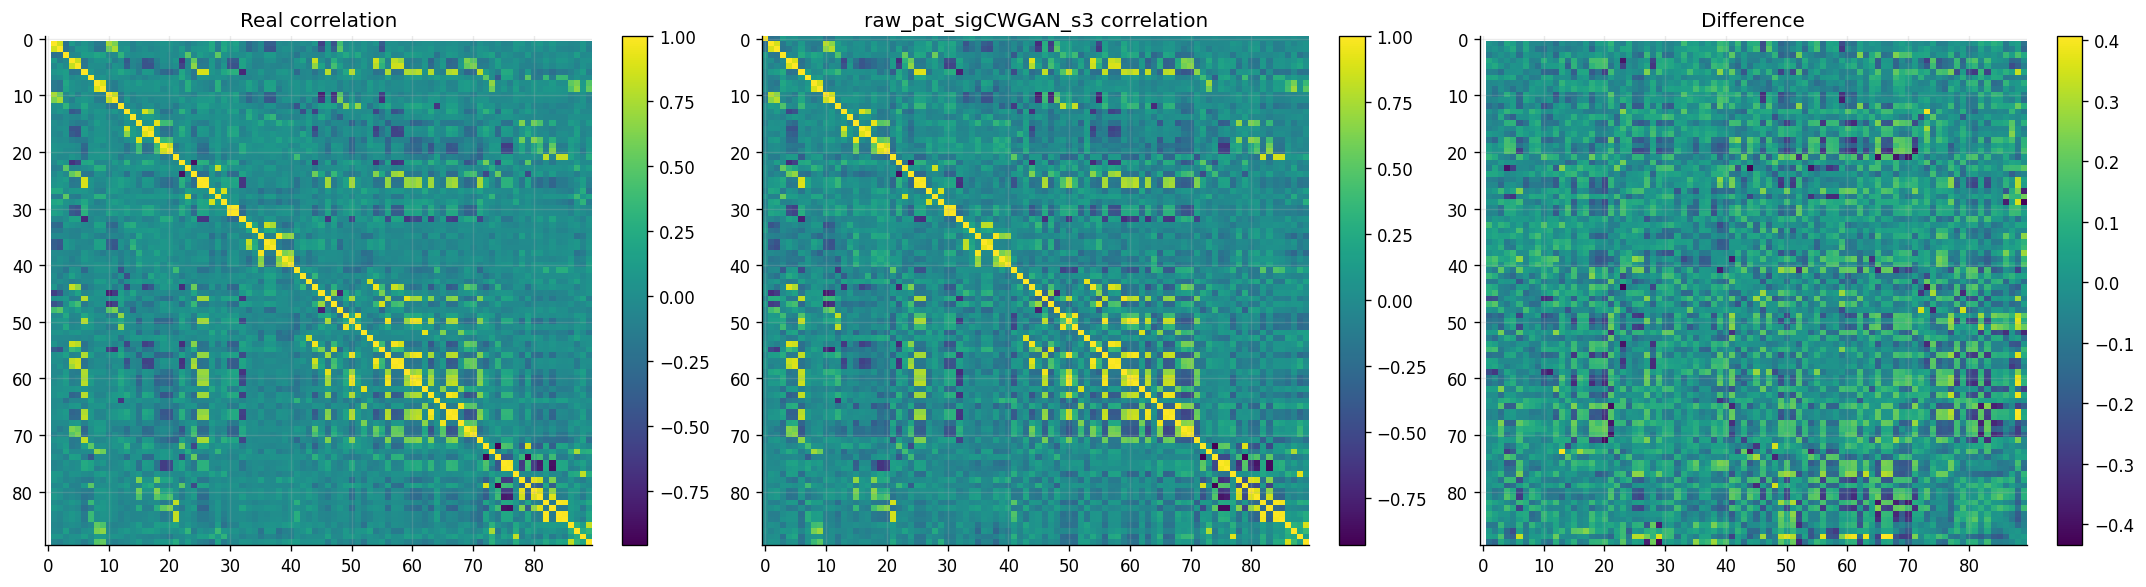

In [22]:

# ═══════════════════════════════════════════════════════════════════════════
# CELL 5 — Test 2: Correlation structure + PCA geometry
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 72)
print("TEST 2: Correlation structure and PCA geometry")
print("=" * 72)

corr_frob = np.nan
corr_max_abs = np.nan
pca_ev_gap = np.nan

if X_real is not None and X_synth is not None:
    corr_real = np.corrcoef(X_real.T)
    corr_synth = np.corrcoef(X_synth.T)
    corr_diff = corr_real - corr_synth

    corr_frob = float(np.linalg.norm(corr_diff, ord="fro"))
    corr_max_abs = float(np.max(np.abs(corr_diff)))

    pca = PCA(n_components=min(5, X_real.shape[1]))
    pca.fit(X_real)
    ev_real = pca.explained_variance_ratio_
    ev_synth = PCA(n_components=min(5, X_synth.shape[1])).fit(X_synth).explained_variance_ratio_
    pca_ev_gap = float(np.mean(np.abs(ev_real - ev_synth[: len(ev_real)])))

    print(f"Correlation Frobenius gap:      {corr_frob:.4f}")
    print(f"Max abs correlation error:      {corr_max_abs:.4f}")
    print(f"Mean PCA explained-var gap:     {pca_ev_gap:.4f}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, mat, title in zip(
        axes,
        [corr_real, corr_synth, corr_diff],
        ["Real correlation", f"{MODEL_NAME} correlation", "Difference"],
    ):
        im = ax.imshow(mat, aspect="auto")
        ax.set_title(title)
        plt.colorbar(im, ax=ax, fraction=0.045)

    plt.tight_layout()
    fig.savefig(FIG_DIR / f"validation_{MODEL_NAME}_correlation.png", bbox_inches="tight")
    plt.show()
else:
    print("[skip] No shared logsig representation available.")


In [23]:

# ═══════════════════════════════════════════════════════════════════════════
# CELL 6 — Test 3: Regime-conditional quality
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 72)
print("TEST 3: Regime-conditional quality")
print("=" * 72)

regime_results = {}
regime_return_gap = {}
coarse4_results = {}

if X_real is not None and X_synth is not None:
    labels = sorted(set(regimes_real.tolist()))
    from scipy.stats import wasserstein_distance

    for reg in labels:
        mask_r = regimes_real == reg
        mask_s = regimes_synth == reg
        nr, ns = int(mask_r.sum()), int(mask_s.sum())
        if nr < MIN_REGIME_SAMPLES or ns < MIN_REGIME_SAMPLES:
            regime_results[reg] = {"n_real": nr, "n_synth": ns, "mean_w1": None, "return_w1": None}
            print(f"{reg:28s} -> insufficient samples (real={nr}, synth={ns})")
            continue
        w1s = [wasserstein_distance(X_real[mask_r, j], X_synth[mask_s, j]) for j in range(X_real.shape[1])]
        ret_w1 = wasserstein_distance(return_real[mask_r], return_synth[mask_s])
        regime_results[reg] = {
            "n_real": nr,
            "n_synth": ns,
            "mean_w1": float(np.mean(w1s)),
            "return_w1": float(ret_w1),
        }
        print(f"{reg:28s} -> mean W1={np.mean(w1s):.4f} | return W1={ret_w1:.4f}")

    # Also produce coarse-4 view if refined labels are present
    coarse_real = np.array([COARSE_REGIME_MAP.get(x, x) for x in regimes_real], dtype=object)
    coarse_synth = np.array([COARSE_REGIME_MAP.get(x, x) for x in regimes_synth], dtype=object)
    for reg in ["calm", "volatile", "spike", "negative"]:
        mask_r = coarse_real == reg
        mask_s = coarse_synth == reg
        nr, ns = int(mask_r.sum()), int(mask_s.sum())
        if nr < MIN_REGIME_SAMPLES or ns < MIN_REGIME_SAMPLES:
            coarse4_results[reg] = {"n_real": nr, "n_synth": ns, "mean_w1": None}
            continue
        w1s = [wasserstein_distance(X_real[mask_r, j], X_synth[mask_s, j]) for j in range(X_real.shape[1])]
        coarse4_results[reg] = {"n_real": nr, "n_synth": ns, "mean_w1": float(np.mean(w1s))}

    display(pd.DataFrame(regime_results).T.sort_values(["mean_w1", "n_real"], ascending=[True, False], na_position="last"))
    display(pd.DataFrame(coarse4_results).T)
else:
    print("[skip] No shared logsig representation available.")



TEST 3: Regime-conditional quality
calm_high_wind_calm          -> mean W1=1.5766 | return W1=0.6850
calm_low_wind_calm           -> mean W1=1.8520 | return W1=0.4347
calm_mid_wind_calm           -> mean W1=0.9724 | return W1=0.2504
negative                     -> mean W1=1.8414 | return W1=0.2496
spike_extreme_brief          -> mean W1=5.2027 | return W1=0.3150
spike_extreme_sustained      -> mean W1=3.7319 | return W1=0.6667
volatile                     -> mean W1=1.3517 | return W1=0.2386


,n_real,n_synth,mean_w1,return_w1
calm_mid_wind_calm,131.0,131.0,0.972438,0.250411
volatile,387.0,387.0,1.351665,0.238576
calm_high_wind_calm,109.0,109.0,1.576595,0.684956
negative,172.0,169.0,1.841386,0.249639
calm_low_wind_calm,103.0,103.0,1.852031,0.434693
spike_extreme_sustained,40.0,40.0,3.731897,0.666698
spike_extreme_brief,30.0,30.0,5.202723,0.315023


,n_real,n_synth,mean_w1
calm,343.0,343.0,1.003904
volatile,387.0,387.0,1.351665
spike,70.0,70.0,3.528560
negative,172.0,169.0,1.841386



TEST 4: Tail behaviour and Lévy-area proxy
Return-proxy tail metrics:
  left_cvar_real    : -2.948973795126595
  left_cvar_synth   : -3.1899374261194344
  right_cvar_real   : 3.000226217534486
  right_cvar_synth  : 3.016572129969694
  hill_abs_real     : 0.22211188697131307
  hill_abs_synth    : 0.1708997222064057
  left_cvar_gap     : 0.24096363099283957
  right_cvar_gap    : 0.01634591243520811
  hill_gap          : 0.051212164764907364
Lévy proxy metrics: {'levy_col': 'ls_7', 'levy_w1': 2.063345483915035, 'levy_ks': 0.11062378167641325, 'levy_mean_real': 25.61647476373965, 'levy_mean_synth': 25.958859298005315}


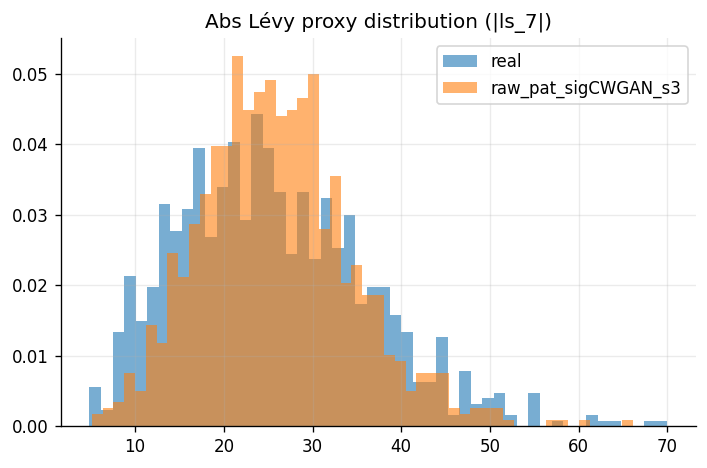

In [24]:

# ═══════════════════════════════════════════════════════════════════════════
# CELL 7 — Test 4: Tail behaviour + Lévy-area proxy
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 72)
print("TEST 4: Tail behaviour and Lévy-area proxy")
print("=" * 72)

tail_metrics = {}
levy_metrics = {}

if return_real is not None and return_synth is not None:
    tail_metrics = {
        "left_cvar_real": left_cvar(return_real, TAIL_ALPHA),
        "left_cvar_synth": left_cvar(return_synth, TAIL_ALPHA),
        "right_cvar_real": right_cvar(return_real, TAIL_ALPHA),
        "right_cvar_synth": right_cvar(return_synth, TAIL_ALPHA),
        "hill_abs_real": hill_estimator_abs(return_real),
        "hill_abs_synth": hill_estimator_abs(return_synth),
    }
    tail_metrics["left_cvar_gap"] = safe_float(abs(tail_metrics["left_cvar_real"] - tail_metrics["left_cvar_synth"]))
    tail_metrics["right_cvar_gap"] = safe_float(abs(tail_metrics["right_cvar_real"] - tail_metrics["right_cvar_synth"]))
    if tail_metrics["hill_abs_real"] is not None and tail_metrics["hill_abs_synth"] is not None:
        tail_metrics["hill_gap"] = safe_float(abs(tail_metrics["hill_abs_real"] - tail_metrics["hill_abs_synth"]))
    else:
        tail_metrics["hill_gap"] = None

    print("Return-proxy tail metrics:")
    for k, v in tail_metrics.items():
        print(f"  {k:18s}: {v}")

if X_real is not None and X_synth is not None and "ls_7" in ls_cols:
    j = ls_cols.index("ls_7")
    from scipy.stats import wasserstein_distance, ks_2samp
    levy_real = np.abs(X_real[:, j])
    levy_synth = np.abs(X_synth[:, j])

    levy_metrics = {
        "levy_col": "ls_7",
        "levy_w1": float(wasserstein_distance(levy_real, levy_synth)),
        "levy_ks": float(ks_2samp(levy_real, levy_synth).statistic),
        "levy_mean_real": safe_float(np.mean(levy_real)),
        "levy_mean_synth": safe_float(np.mean(levy_synth)),
    }
    print("Lévy proxy metrics:", levy_metrics)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(levy_real, bins=50, alpha=0.6, density=True, label="real")
    ax.hist(levy_synth, bins=50, alpha=0.6, density=True, label=MODEL_NAME)
    ax.set_title("Abs Lévy proxy distribution (|ls_7|)")
    ax.legend()
    plt.tight_layout()
    fig.savefig(FIG_DIR / f"validation_{MODEL_NAME}_levy.png", bbox_inches="tight")
    plt.show()
else:
    print("[info] ls_7 not available; Lévy proxy skipped.")



TEST 5: Temporal structure and event-proxy realism
Temporal metrics:
  return_acf_gap            : 0.08616806942312777
  return_half_life_real     : 0.2005191018790136
  return_half_life_synth    : 0.13989026367770363
  return_half_life_gap      : 0.06062883820130996
Event-proxy metrics:
  event_threshold_abs_return: 2.7780518984181772
  event_rate_real           : 0.050411522633744855
  event_rate_synth          : 0.07430340557275542
  event_rate_gap            : 0.02389188293901056
  event_acf_gap             : 0.034190177770294906


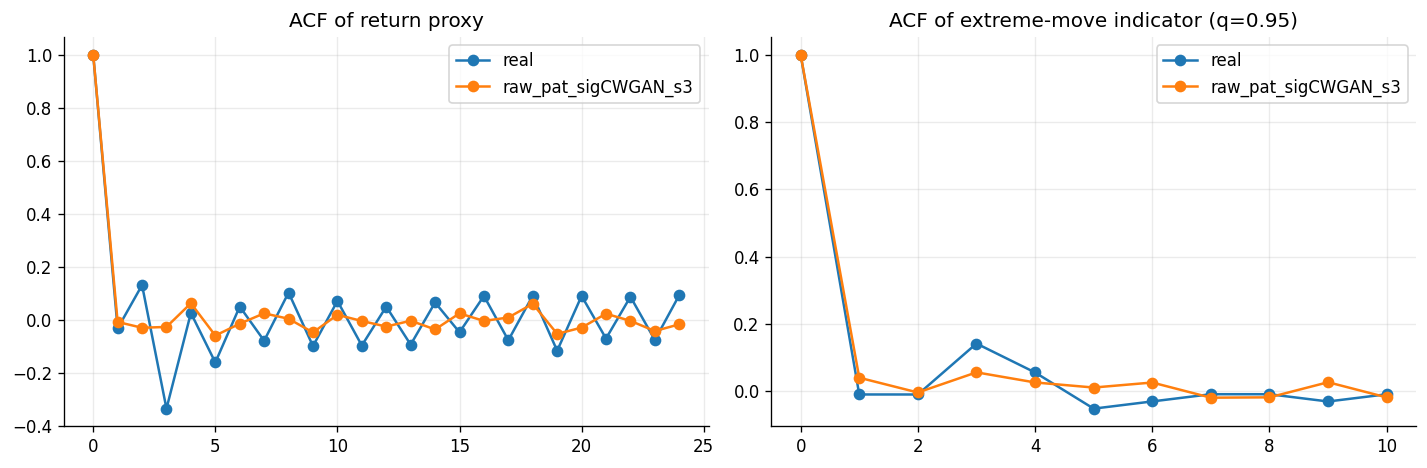

In [25]:

# ═══════════════════════════════════════════════════════════════════════════
# CELL 8 — Test 5: Temporal structure + event proxies
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 72)
print("TEST 5: Temporal structure and event-proxy realism")
print("=" * 72)

temporal_metrics = {}
event_metrics = {}

if return_real is not None and return_synth is not None:
    acf_mean_gap, acf_real_ret, acf_synth_ret = acf_gap(return_real, return_synth, nlags=MAX_LAGS)
    temporal_metrics["return_acf_gap"] = safe_float(acf_mean_gap)
    temporal_metrics["return_half_life_real"] = safe_float(ar1_half_life(return_real))
    temporal_metrics["return_half_life_synth"] = safe_float(ar1_half_life(return_synth))
    if temporal_metrics["return_half_life_real"] is not None and temporal_metrics["return_half_life_synth"] is not None:
        temporal_metrics["return_half_life_gap"] = safe_float(abs(
            temporal_metrics["return_half_life_real"] - temporal_metrics["return_half_life_synth"]
        ))
    else:
        temporal_metrics["return_half_life_gap"] = None

    print("Temporal metrics:")
    for k, v in temporal_metrics.items():
        print(f"  {k:26s}: {v}")

    evt_real, evt_thr = event_indicator(return_real, EVENT_Q)
    evt_synth = (np.abs(return_synth) >= evt_thr).astype(float)

    event_metrics["event_threshold_abs_return"] = evt_thr
    event_metrics["event_rate_real"] = safe_float(np.mean(evt_real))
    event_metrics["event_rate_synth"] = safe_float(np.mean(evt_synth))
    event_metrics["event_rate_gap"] = safe_float(abs(event_metrics["event_rate_real"] - event_metrics["event_rate_synth"]))

    evt_acf_gap_val, evt_acf_real, evt_acf_synth = acf_gap(evt_real, evt_synth, nlags=min(10, MAX_LAGS))
    event_metrics["event_acf_gap"] = safe_float(evt_acf_gap_val)

    print("Event-proxy metrics:")
    for k, v in event_metrics.items():
        print(f"  {k:26s}: {v}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    if acf_real_ret is not None and acf_synth_ret is not None:
        axes[0].plot(acf_real_ret, marker="o", label="real")
        axes[0].plot(acf_synth_ret, marker="o", label=MODEL_NAME)
        axes[0].set_title("ACF of return proxy")
        axes[0].legend()
    if evt_acf_real is not None and evt_acf_synth is not None:
        axes[1].plot(evt_acf_real, marker="o", label="real")
        axes[1].plot(evt_acf_synth, marker="o", label=MODEL_NAME)
        axes[1].set_title(f"ACF of extreme-move indicator (q={EVENT_Q:.2f})")
        axes[1].legend()

    plt.tight_layout()
    fig.savefig(FIG_DIR / f"validation_{MODEL_NAME}_temporal.png", bbox_inches="tight")
    plt.show()
else:
    print("[skip] Return-proxy temporal tests unavailable.")


In [26]:

# ═══════════════════════════════════════════════════════════════════════════
# CELL 9 — Test 6: Optional structural realism checks
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 72)
print("TEST 6: Optional structural realism checks")
print("=" * 72)

structural_metrics = {"notes": []}

# 1) Regime transition comparison only if regime is not obviously copied
if "regime" in df_real.columns and "regime" in df_synth.columns:
    if copied_meta_flags.get("regime") is True:
        structural_metrics["notes"].append("Regime column appears copied into synthetic file; transition comparison skipped.")
        print("[info] Regime column appears copied; transition comparison skipped.")
    else:
        uniq_r, T_r = transition_matrix(regimes_real)
        uniq_s, T_s = transition_matrix(regimes_synth)
        if uniq_r == uniq_s and T_r.shape == T_s.shape:
            structural_metrics["regime_transition_l1_gap"] = matrix_l1_gap(T_r, T_s)
            print("regime_transition_l1_gap:", structural_metrics["regime_transition_l1_gap"])
        else:
            structural_metrics["notes"].append("Regime label sets differ between real and synthetic; transition comparison skipped.")
            print("[info] Regime label sets differ; transition comparison skipped.")

# 2) Wind-sensitivity beta only if the needed columns are present and not copied
y_col, x_col = maybe_find_uncopied_numeric_pair(
    df_real, df_synth,
    y_candidates=["mean_price", "realised_vol", "ls_1"],
    x_candidates=["mean_wind", "wind_prev_mean", "cond_wind_prev_mean"]
)
if y_col is not None and x_col is not None:
    beta_real = beta_of_y_on_x(df_real[y_col], df_real[x_col])
    beta_synth = beta_of_y_on_x(df_synth[y_col], df_synth[x_col])
    structural_metrics["beta_col_y"] = y_col
    structural_metrics["beta_col_x"] = x_col
    structural_metrics["beta_real"] = beta_real
    structural_metrics["beta_synth"] = beta_synth
    structural_metrics["beta_gap"] = safe_float(abs(beta_real - beta_synth))
    print(f"beta({y_col} ~ {x_col}) real : {beta_real}")
    print(f"beta({y_col} ~ {x_col}) synth: {beta_synth}")
    print(f"beta gap: {structural_metrics['beta_gap']}")
else:
    structural_metrics["notes"].append("No usable uncopied (y, x) pair found for wind-sensitivity beta.")
    print("[info] No usable uncopied (y, x) pair found for beta check.")

if not structural_metrics["notes"]:
    structural_metrics["notes"] = None

print("Structural metrics:", structural_metrics)



TEST 6: Optional structural realism checks
regime_transition_l1_gap: 0.0002330917229971682
beta(mean_price ~ mean_wind) real : -0.0023326017851034624
beta(mean_price ~ mean_wind) synth: -0.0023354997713004584
beta gap: 2.8979861969959976e-06
Structural metrics: {'notes': None, 'regime_transition_l1_gap': 0.0002330917229971682, 'beta_col_y': 'mean_price', 'beta_col_x': 'mean_wind', 'beta_real': -0.0023326017851034624, 'beta_synth': -0.0023354997713004584, 'beta_gap': 2.8979861969959976e-06}



TEST 7: Signature-space MMD
MMD metrics: {'n_mmd': 969, 'mmd_rbf_logsig': 0.008163210897583983, 'gamma': 0.008906701726280218}


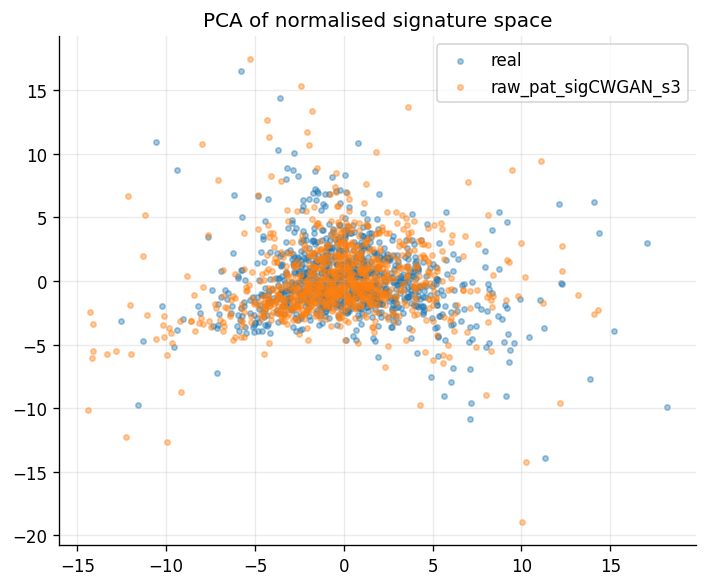

In [27]:

# ═══════════════════════════════════════════════════════════════════════════
# CELL 10 — Test 7: Signature-space MMD
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 72)
print("TEST 7: Signature-space MMD")
print("=" * 72)

mmd_metrics = {}

if X_real is not None and X_synth is not None:
    n_use = min(N_MMD, len(X_real), len(X_synth))
    np.random.seed(42)
    idx_r = np.random.choice(len(X_real), n_use, replace=False)
    idx_s = np.random.choice(len(X_synth), n_use, replace=False)

    Xr = X_real[idx_r]
    Xs = X_synth[idx_s]
    Xr_n, Xs_n = normalise_for_kernel(Xr, Xs)
    mmd_val, gamma_used = rbf_mmd(Xr_n, Xs_n, gamma=MMD_GAMMA)

    mmd_metrics = {
        "n_mmd": int(n_use),
        "mmd_rbf_logsig": mmd_val,
        "gamma": gamma_used,
    }
    print("MMD metrics:", mmd_metrics)

    # simple PCA view
    pca = PCA(n_components=2)
    Z = pca.fit_transform(np.vstack([Xr_n, Xs_n]))
    Zr = Z[: len(Xr_n)]
    Zs = Z[len(Xr_n):]

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(Zr[:, 0], Zr[:, 1], s=10, alpha=0.4, label="real")
    ax.scatter(Zs[:, 0], Zs[:, 1], s=10, alpha=0.4, label=MODEL_NAME)
    ax.set_title("PCA of normalised signature space")
    ax.legend()
    plt.tight_layout()
    fig.savefig(FIG_DIR / f"validation_{MODEL_NAME}_pca.png", bbox_inches="tight")
    plt.show()
else:
    print("[skip] No shared logsig representation available.")


In [28]:

# ═══════════════════════════════════════════════════════════════════════════
# CELL 11 — Summary, composite score, and save
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 72)
print(f"VALIDATION SUMMARY — {MODEL_NAME}")
print("=" * 72)

tail_gap_for_score = np.nanmean([
    val if val is not None else np.nan
    for val in [
        tail_metrics.get("left_cvar_gap"),
        tail_metrics.get("right_cvar_gap"),
        tail_metrics.get("hill_gap")
    ]
]) if tail_metrics else np.nan

event_gap_for_score = np.nanmean([
    val if val is not None else np.nan
    for val in [
        event_metrics.get("event_rate_gap"),
        event_metrics.get("event_acf_gap")
    ]
]) if event_metrics else np.nan

levy_gap_for_score = levy_metrics.get("levy_w1", np.nan) if levy_metrics else np.nan
mmd_for_score = mmd_metrics.get("mmd_rbf_logsig", np.nan) if mmd_metrics else np.nan
acf_gap_for_score = temporal_metrics.get("return_acf_gap", np.nan) if temporal_metrics else np.nan

components_for_score = {
    "mmd": mmd_for_score,
    "mean_gap": mean_gap,
    "std_gap": std_gap,
    "acf_gap": acf_gap_for_score,
    "levy_gap": levy_gap_for_score,
    "tail_gap": tail_gap_for_score,
    "event_gap": event_gap_for_score,
}
composite_score = 0.0
active_weight = 0.0
for k, w in SCORE_WEIGHTS.items():
    v = components_for_score.get(k, np.nan)
    if v is not None and np.isfinite(v):
        composite_score += w * float(v)
        active_weight += float(w)
composite_score = composite_score if active_weight > 0 else np.nan

# Build a contribution table as well as the raw metric table
rows = []
for k in components_for_score.keys():
    value = components_for_score.get(k, np.nan)
    weight = SCORE_WEIGHTS.get(k, np.nan)

    valid = (
        value is not None and np.isfinite(value) and
        weight is not None and np.isfinite(weight)
    )

    contribution = float(weight) * float(value) if valid else np.nan
    rows.append({
        "metric": k,
        "value": value,
        "weight": weight,
        "weighted_contribution": contribution,
    })

summary_table = pd.DataFrame(rows)

# Optional: show contribution as % of total weighted score
if np.isfinite(composite_score) and composite_score != 0:
    summary_table["pct_of_total_score"] = 100.0 * summary_table["weighted_contribution"] / composite_score
else:
    summary_table["pct_of_total_score"] = np.nan

display(summary_table)

print(f"Composite validation score (lower better): {composite_score}")

print("\nWeighted contribution by term:")
for _, row in summary_table.sort_values("weighted_contribution", ascending=False, na_position="last").iterrows():
    metric = row["metric"]
    value = row["value"]
    weight = row["weight"]
    contrib = row["weighted_contribution"]
    pct = row["pct_of_total_score"]

    value_str = f"{value:.6f}" if value is not None and np.isfinite(value) else "nan"
    weight_str = f"{weight:.2f}" if weight is not None and np.isfinite(weight) else "nan"
    contrib_str = f"{contrib:.6f}" if contrib is not None and np.isfinite(contrib) else "nan"
    pct_str = f"{pct:.1f}%" if pct is not None and np.isfinite(pct) else "nan"

    print(
        f"  {metric:>10s} | value={value_str:>10s} | "
        f"weight={weight_str:>5s} | contrib={contrib_str:>10s} | share={pct_str}"
    )

print(f"Composite validation score (lower better): {composite_score}")

report = {
    "model_name": MODEL_NAME,
    "real_file": REAL_FILE.name,
    "synth_file": SYNTH_FILE.name,
    "target_split": TARGET_SPLIT,
    "real_format_declared": REAL_FORMAT,
    "synth_format_declared": SYNTH_FORMAT,
    "representation_mode": representation_mode,
    "regime_mode_used": regime_mode_real,
    "n_real": int(len(df_real)),
    "n_synth": int(len(df_synth)),
    "n_logsig_dims": int(len(ls_cols)),
    "path_channels_used": path_channels,
    "copied_meta_flags": copied_meta_flags,
    "score_weights": SCORE_WEIGHTS,
    "composite_validation_score": safe_float(composite_score),
    "distributional_fidelity": {
        "mean_wasserstein_1": safe_float(mean_w1),
        "mean_ks_stat": safe_float(mean_ks),
        "aggregate_mean_gap": safe_float(mean_gap),
        "aggregate_std_gap": safe_float(std_gap),
        "tail_metrics": tail_metrics,
        "levy_metrics": levy_metrics,
        "mmd_metrics": mmd_metrics,
    },
    "correlation_geometry": {
        "corr_frobenius_norm": safe_float(corr_frob),
        "corr_max_abs": safe_float(corr_max_abs),
        "pca_explained_var_gap": safe_float(pca_ev_gap),
    },
    "temporal_structure": temporal_metrics,
    "event_proxy_realism": event_metrics,
    "regime_conditional": {
        "dynamic": regime_results,
        "coarse4": coarse4_results,
    },
    "structural_realism_optional": structural_metrics,
    "summary_stats_return_proxy": {
        "real": summary_stats(return_real) if return_real is not None else None,
        "synth": summary_stats(return_synth) if return_synth is not None else None,
    },
    "summary_stats_aux_proxy": {
        "real": summary_stats(aux_real) if aux_real is not None else None,
        "synth": summary_stats(aux_synth) if aux_synth is not None else None,
    },
}

with open(OUTPUT_JSON, "w") as f:
    json.dump(report, f, indent=2)

print(f"Saved report to: {OUTPUT_JSON}")
print("\nQuick read:")
print(f"  n_real / n_synth         : {len(df_real)} / {len(df_synth)}")
print(f"  logsig dims              : {len(ls_cols)}")
print(f"  mean gap / std gap       : {mean_gap} / {std_gap}")
print(f"  MMD                      : {mmd_metrics.get('mmd_rbf_logsig') if mmd_metrics else None}")
print(f"  return ACF gap           : {temporal_metrics.get('return_acf_gap') if temporal_metrics else None}")
print(f"  event rate gap           : {event_metrics.get('event_rate_gap') if event_metrics else None}")
print(f"  composite score          : {composite_score}")



VALIDATION SUMMARY — raw_pat_sigCWGAN_s3


,metric,value,weight,weighted_contribution,pct_of_total_score
0,mmd,0.008163,1.00,0.008163,0.571882
1,mean_gap,0.699924,0.25,0.174981,12.258483
2,std_gap,0.619423,1.00,0.619423,43.394335
3,acf_gap,0.086168,0.50,0.043084,3.018297
4,levy_gap,2.063345,0.25,0.515836,36.137452
5,tail_gap,0.102841,0.50,0.051420,3.602301
6,event_gap,0.029041,0.50,0.014521,1.017250


Composite validation score (lower better): 1.4274287247772453

Weighted contribution by term:
     std_gap | value=  0.619423 | weight= 1.00 | contrib=  0.619423 | share=43.4%
    levy_gap | value=  2.063345 | weight= 0.25 | contrib=  0.515836 | share=36.1%
    mean_gap | value=  0.699924 | weight= 0.25 | contrib=  0.174981 | share=12.3%
    tail_gap | value=  0.102841 | weight= 0.50 | contrib=  0.051420 | share=3.6%
     acf_gap | value=  0.086168 | weight= 0.50 | contrib=  0.043084 | share=3.0%
   event_gap | value=  0.029041 | weight= 0.50 | contrib=  0.014521 | share=1.0%
         mmd | value=  0.008163 | weight= 1.00 | contrib=  0.008163 | share=0.6%
Composite validation score (lower better): 1.4274287247772453
Saved report to: /content/drive/MyDrive/energy_synthetic_data/data/validation_raw_pat_sigCWGAN_s3.json

Quick read:
  n_real / n_synth         : 972 / 969
  logsig dims              : 90
  mean gap / std gap       : 0.6999244232776413 / 0.619423202493776
  MMD              

### Notes for the other streams

- **SigCWGAN**: point `SYNTH_FILE` to `sigcwgan_generated_logsigs.parquet`.
- **Neural SDE**:
  - if you already wrote `logsigs_s4.parquet`, point the notebook at that
  - if you only have raw wide paths, set `SYNTH_FORMAT = "raw_paths"` and let this notebook try to build a shared raw-path representation
- **Diffusion**:
  - same rule as Neural SDE
  - if the diffusion output is raw returns or raw prices in wide format, keep the numeric suffix naming clean so the raw-path branch can detect the channel groups

For honest apples-to-apples comparison, keep `TARGET_SPLIT = "test"` unless you are doing an explicit diagnostic run.
